# K-Means Clustering

**K-Means** is one of the most popular **unsupervised machine learning algorithms** used to group similar data points into different clusters.

Unlike supervised learning, there are **no labels** provided. The algorithm tries to discover hidden patterns in the data by grouping similar observations together.

The main objective is:

- Data points within the **same cluster** should be as similar as possible.
- Data points belonging to **different clusters** should be as different as possible.

---

# 1. Core Intuition

Imagine you have information about students based on:

- CGPA
- IQ

When plotted on a graph, you might naturally notice three groups of students.

As humans, we can visually identify these groups.

K-Means tries to do exactly the same—but mathematically.

It automatically finds these groups without knowing any labels beforehand.

---

# 2. The Basic Idea

The algorithm works by creating **K groups (clusters)**.

Each cluster is represented by a point called a **Centroid**.

A centroid is simply the **center of a cluster**.

Every data point belongs to the cluster whose centroid is closest to it.

---

# 3. Step-by-Step Algorithm

## Step 1: Choose the Number of Clusters (K)

Before running the algorithm, we must specify:

```
How many clusters do we want?
```

Example:

```
K = 3
```

means we want to divide the data into **3 groups**.

---

## Step 2: Initialize the Centroids

The algorithm randomly places **K centroids** in the feature space.

These are only temporary starting points.

For example:

```
       ●

                  ●

     ●
```

These centroids usually do **not** represent the true centers initially.

---

## Step 3: Assign Every Point to the Nearest Centroid

Now every data point calculates which centroid is closest.

Suppose we have three centroids:

```
Red
Blue
Green
```

Each data point joins the nearest centroid.

After this step, temporary clusters are formed.

```
🔴 🔴 🔴

🔵 🔵 🔵

🟢 🟢 🟢
```

---

## Step 4: Move the Centroids

Now each centroid moves to the **center of all points assigned to it**.

Think of it like this:

Instead of staying at its random position,

the centroid asks,

> "Where is the average location of all my assigned points?"

It then moves there.

The clusters now look much better.

---

## Step 5: Reassign Points

Since the centroids have moved,

some border points may now be closer to another centroid.

Those points change clusters.

Example:

```
Initially

🔴 🔴 🔴 🔴

      🔵

After centroid movement

🔴 🔴 🔴

🔵 🔵
```

Some points switch from Red to Blue because Blue became closer.

---

## Step 6: Repeat

The algorithm keeps repeating:

```
Assign points

↓

Move centroids

↓

Assign again

↓

Move again
```

until nothing changes anymore.

---

# 4. When Does K-Means Stop?

The algorithm stops when one of these happens:

### 1. Centroids stop moving

Their positions remain the same.

---

### 2. No data point changes its cluster

Every point already belongs to its nearest centroid.

---

### 3. Maximum iterations are reached

A predefined iteration limit prevents infinite looping.

---

# 5. Geometric Intuition

Imagine placing three magnets on a table filled with iron particles.

Initially,

the magnets are placed randomly.

```
Random Magnets

●        ●

      ●
```

The particles move toward the nearest magnet.

Now each magnet shifts toward the center of the particles attached to it.

As magnets move,

some particles become closer to another magnet,

so they switch.

Eventually,

every magnet sits exactly at the center of its own particles.

Nothing changes anymore.

This is exactly how K-Means works.

---

# 6. Choosing the Right Number of Clusters (The Elbow Method)

One major problem with K-Means is:

> How do we know the correct value of K?

The most common solution is the **Elbow Method**.

---

## The Idea

Run K-Means multiple times.

Example:

```
K = 1

K = 2

K = 3

K = 4

...

K = 10
```

For every value of K,

calculate how compact the clusters are.

As K increases,

clusters naturally become smaller and tighter.

So the clustering quality improves.

However,

after a certain point,

adding more clusters gives only a tiny improvement.

---

## The Elbow Curve

Plot

```
K
vs
WCSS (Within-Cluster Sum of Squares)
```

The graph usually looks like:

```
WCSS

|
|\
| \
|  \
|   \
|    \__
|       \__
|          \__
|
+----------------------> K
```

Initially,

the curve drops rapidly.

After some point,

it starts becoming almost flat.

The point where this bend occurs is called the **Elbow Point**.

---

## Why is it Called the Elbow?

The graph resembles the bend of a human arm.

```
   \
    \
     \
      \__
         \
```

The bend represents the best trade-off between:

- Too few clusters
- Too many clusters

The K at this bend is usually chosen.

---

# 7. Advantages

- Simple to understand
- Easy to implement
- Fast on large datasets
- Works well when clusters are clearly separated
- One of the most widely used clustering algorithms

---

# 8. Limitations

- Must specify **K** beforehand.
- Sensitive to random centroid initialization.
- Sensitive to outliers.
- Performs poorly if clusters have irregular shapes.
- Assumes clusters are roughly spherical.

---

# 9. Summary

| Concept | Description |
|---------|-------------|
| Learning Type | Unsupervised Learning |
| Goal | Group similar data points together |
| Main Idea | Assign points to the nearest centroid |
| Centroid | Center of a cluster |
| Algorithm Cycle | Assign → Move Centroid → Repeat |
| Stops When | Centroids stop moving or assignments stop changing |
| Choosing K | Elbow Method |

---

# Overall Workflow

```text
             Unlabeled Dataset
                    │
                    ▼
          Choose Number of Clusters (K)
                    │
                    ▼
         Randomly Initialize Centroids
                    │
                    ▼
      Assign Each Point to Nearest Centroid
                    │
                    ▼
        Recalculate Centroid Positions
                    │
                    ▼
       Did Any Centroid or Assignment Change?
             │                     │
           Yes                    No
             │                     │
             └──────────────► Final Clusters
```

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('student_clustering.csv')

print('Shape of the data :', df.shape)
df.head()

Shape of the data : (200, 2)


,cgpa,iq
0,5.13,88
1,5.90,113
2,8.36,93
3,8.27,97
4,5.45,110


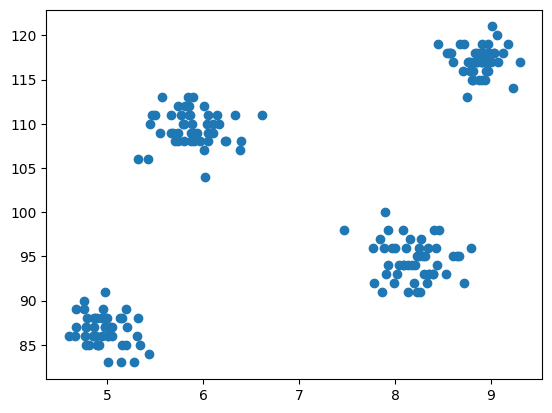

In [6]:
# lets Visualise the data in 2D 
plt.scatter(df['cgpa'],df['iq'])

In [7]:
from sklearn.cluster import KMeans

In [9]:
# Lets create a func and run a loop and find the best no of clusters 

wcss = []

for i in range(1,11):
    km = KMeans(n_clusters=i)  # no of clusters
    km.fit_predict(df)         # train & predict
    wcss.append(km.inertia_)   
    

D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

In [10]:
wcss

[29957.898287999997,
 4184.14127,
 2503.3975809999997,
 681.96966,
 611.7320487706855,
 427.96277698772144,
 355.06958246611913,
 242.25461777981252,
 220.410062416493,
 195.99630740698868]

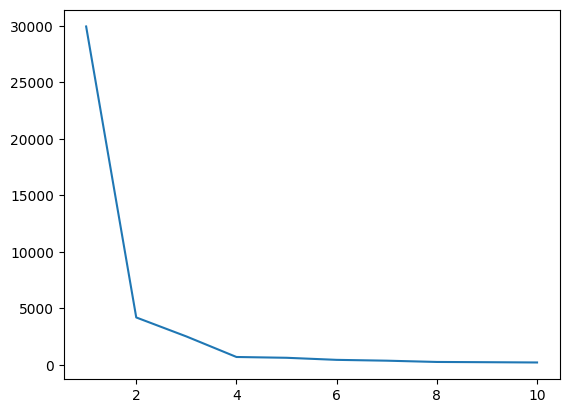

In [11]:
plt.plot(range(1,11),wcss)

In [12]:
# as per the elbow method after 4 the grph becomes flat 

In [13]:
# Lets the best no of clusters -> 4

x = df.iloc[:,:].values  # converting into dataframe , for better handling 
km = KMeans(n_clusters=4)
y_means = km.fit_predict(x) 

y_means

D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([0, 1, 2, 2, 1, 1, 2, 3, 1, 2, 0, 1, 2, 0, 1, 2, 1, 2, 1, 1, 2, 0,
       2, 0, 0, 2, 0, 3, 2, 1, 3, 1, 3, 1, 2, 2, 3, 1, 0, 1, 0, 2, 2, 0,
       3, 3, 2, 1, 3, 1, 0, 0, 3, 2, 3, 1, 1, 3, 1, 3, 1, 2, 2, 3, 0, 3,
       2, 0, 1, 2, 1, 3, 2, 0, 1, 3, 1, 3, 0, 2, 2, 3, 1, 0, 3, 0, 3, 1,
       3, 1, 3, 3, 2, 0, 2, 2, 3, 2, 0, 3, 1, 0, 0, 3, 0, 0, 2, 0, 3, 3,
       2, 3, 1, 1, 2, 3, 2, 1, 3, 0, 0, 1, 2, 3, 2, 0, 2, 1, 0, 2, 2, 1,
       0, 0, 1, 3, 1, 0, 2, 2, 2, 0, 1, 0, 0, 3, 0, 3, 1, 0, 3, 0, 3, 3,
       0, 2, 1, 3, 1, 2, 0, 3, 1, 2, 3, 0, 1, 0, 0, 3, 3, 1, 3, 0, 0, 2,
       3, 1, 0, 3, 3, 1, 1, 1, 2, 0, 2, 2, 3, 1, 2, 2, 0, 0, 2, 0, 3, 1,
       1, 3], dtype=int32)

In [20]:
x[y_means == 0,0]
# means =  cluster,column 

array([5.13, 4.6 , 5.  , 4.86, 4.78, 4.96, 4.86, 5.44, 5.34, 5.31, 5.14,
       4.95, 5.21, 4.91, 5.28, 5.15, 4.9 , 4.89, 5.05, 4.98, 5.01, 4.95,
       4.96, 4.85, 4.76, 4.98, 4.78, 5.2 , 5.05, 5.01, 4.77, 4.68, 4.81,
       5.03, 4.98, 5.32, 4.86, 4.89, 4.88, 5.01, 4.67, 5.15, 4.97, 4.87,
       5.2 , 4.99, 4.79, 4.76, 4.78, 4.68])

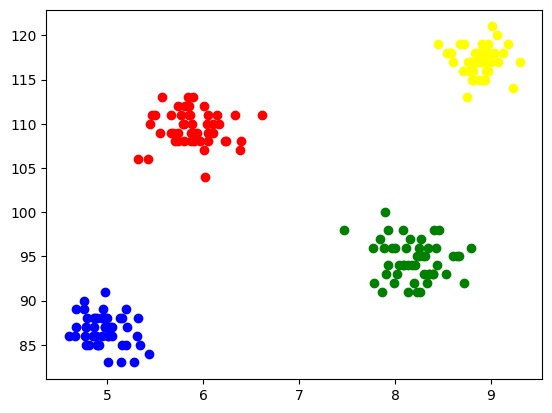

In [15]:
# Assigning colors 

plt.scatter(x[y_means == 0,0],x[y_means == 0,1],color='blue')
plt.scatter(x[y_means == 1,0],x[y_means == 1,1],color='red')
plt.scatter(x[y_means == 2,0],x[y_means == 2,1],color='green')
plt.scatter(x[y_means == 3,0],x[y_means == 3,1],color='yellow')

# K-Means on 3-D Data

In [29]:
from sklearn.datasets import make_blobs

centroids = [(-5,-5,5),(5,5,-5),(3.5,-2.5,4),(-2.5,2.5,-4)]
cluster_std = [1,1,1,1]

x,y = make_blobs(n_samples=200,cluster_std=cluster_std,centers=centroids,n_features=3,random_state=1)

In [30]:
x

array([[ 4.33424548,  3.32580419, -4.17497018],
       [-3.32246719,  3.22171129, -4.625342  ],
       [-6.07296862, -4.13459237,  2.6984613 ],
       [ 6.90465871,  6.1110567 , -4.3409502 ],
       [-2.60839207,  2.95015551, -2.2346649 ],
       [ 5.88490881,  4.12271848, -5.86778722],
       [-4.68484061, -4.15383935,  4.14048406],
       [-1.82542929,  3.96089238, -3.4075272 ],
       [-5.34385368, -4.95640314,  4.37999916],
       [ 4.91549197,  4.70263812, -4.582698  ],
       [-3.80108212, -4.81484358,  4.62471505],
       [ 4.6735005 ,  3.65732421, -3.88561702],
       [-6.23005814, -4.4494625 ,  5.79280687],
       [-3.90232915,  2.95112294, -4.6949209 ],
       [ 3.72744124,  5.31354772, -4.49681519],
       [-3.3088472 ,  3.05743945, -3.81896126],
       [ 2.70273021, -2.21732429,  3.17390257],
       [ 4.06438286, -0.36217193,  3.214466  ],
       [ 4.69268607, -2.73794194,  5.15528789],
       [ 4.1210827 , -1.5438783 ,  3.29415949],
       [-6.61577235, -3.87858229,  5.408

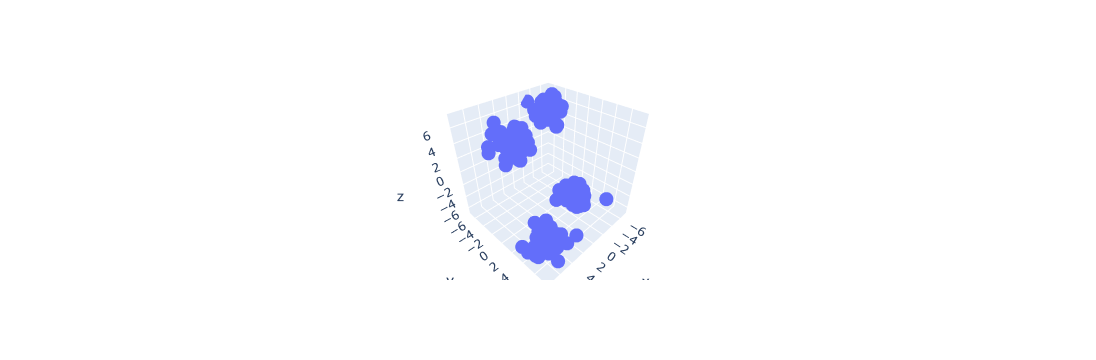

In [31]:
import plotly.express as px
fig = px.scatter_3d(x=x[:,0], y=x[:,1], z=x[:,2])
fig.show()

In [32]:
# same steps as done in 2d

wcss = []
for i in range(1,21):
    km = KMeans(n_clusters=i)
    km.fit_predict(x)
    wcss.append(km.inertia_)

D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the e

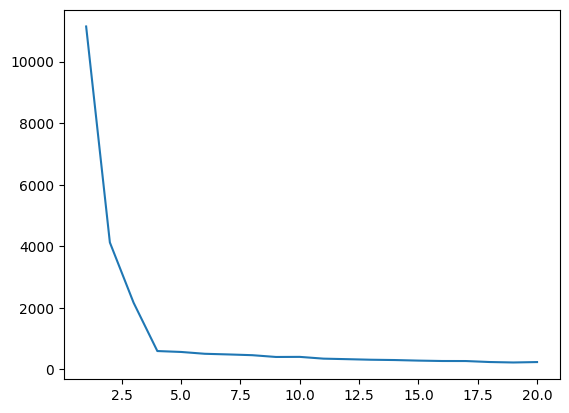

In [33]:
# Findingg the best no of cluster 
plt.plot(range(1,21),wcss)

In [34]:
km = KMeans(n_clusters=4)
y_pred = km.fit_predict(x)

D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



In [35]:
df = pd.DataFrame()

df['col1'] = x[:,0]
df['col2'] = x[:,1]
df['col3'] = x[:,2]
df['label'] = y_pred

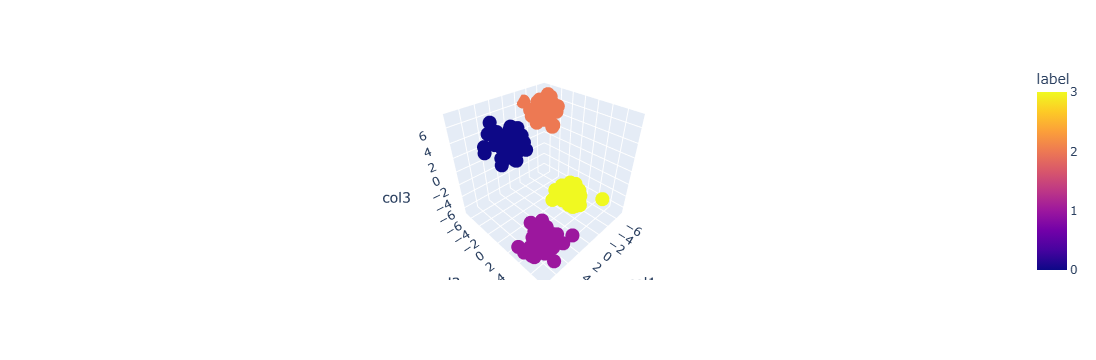

In [36]:
fig = px.scatter_3d(df,x='col1', y='col2', z='col3',color='label')
fig.show()